# Algorithm Explanation



### **What is Random Forest Classification?**

Random Forest Classification is an ensemble learning algorithm used for classification tasks. It builds multiple decision trees using different random subsets of the training data and combines their predictions to produce a more accurate and reliable classification result.

---

### **How It Works**



1. **Bootstrap Sampling:** It creates random subsets of the training dataset (with replacement) to train each individual decision tree.
2. **Feature Bagging:** At each split, each tree considers only a random subset of features. This increases diversity among the trees and improves the model's generalization.
3. **Majority Voting:** Each decision tree predicts a class label, and the final prediction is determined by the majority vote of all trees.



---

### **When to Use It**

* When solving classification problems
(e.g., Yes/No, Survived/Not Survived).
* When the data contains complex and non-linear relationships.
* When working with high-dimensional datasets that have many features.
* When a robust model with high accuracy and good generalization is required.

---

### **Pros & Cons**

| **Advantages**                                                                           | **Limitations**                                                                   |
| ---------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| **High Accuracy:** Combines multiple decision trees to improve prediction performance.   | **Slow Training:** Training many trees requires more computational time.          |
| **Reduces Overfitting:** More stable and reliable than a single Decision Tree.           | **Less Interpretable:** More difficult to explain than a single Decision Tree.    |
| **Robust:** Handles missing values, noisy data, and outliers effectively.                | **Higher Memory Usage:** Requires more memory because it builds multiple trees.   |
| **Feature Importance:** Identifies the most important features affecting the prediction. | **Computationally Expensive:** Can be resource-intensive for very large datasets. |


#EDA

In [20]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [21]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
print("\n======= Data Types =======")
print(df.dtypes)


======= Data Types =======
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [25]:
print("\n======= Target & Features =======")
print("Target Variable: 'Survived'")
print("Key Features: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked")


======= Target & Features =======
Target Variable: 'Survived'
Key Features: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked


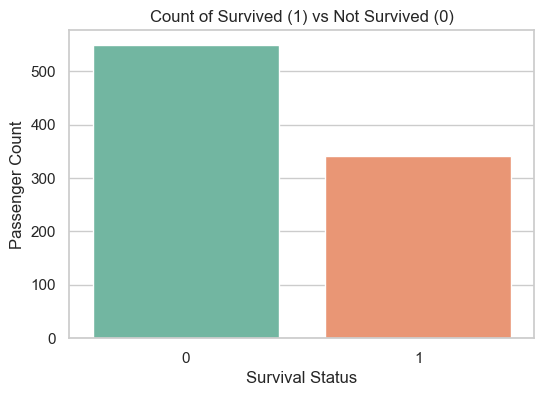

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Survived', palette='Set2', hue='Survived', legend=False)
plt.title('Count of Survived (1) vs Not Survived (0)')
plt.xlabel('Survival Status')
plt.ylabel('Passenger Count')
plt.show()

* **Insight:** The plot clearly demonstrates that the mortality rate was significantly higher than the survival rate. The majority of passengers (over 500) did not survive, while only around 340 passengers managed to escape. This highlights the immense scale of the disaster and the severe limitations of the rescue operations.


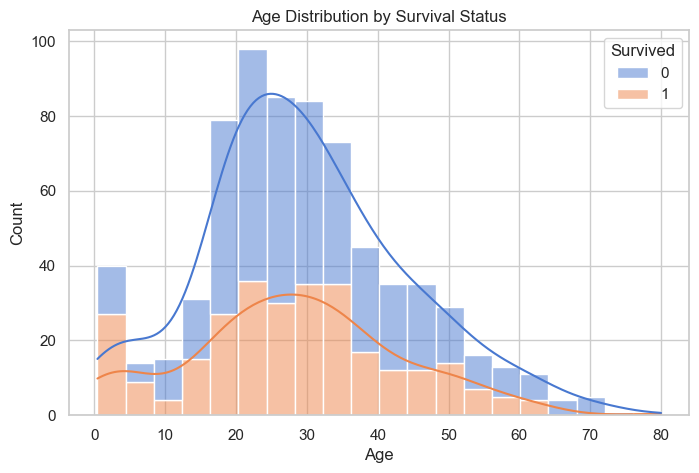

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', kde=True, hue='Survived', multiple='stack', palette='muted')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


* **Insight:** The distribution shows that the majority of the passengers on board were young adults, predominantly concentrated in the **20 to 40 age range**. There is also a small peak representing infants, indicating a diverse age demographic despite the heavy concentration of young adults.

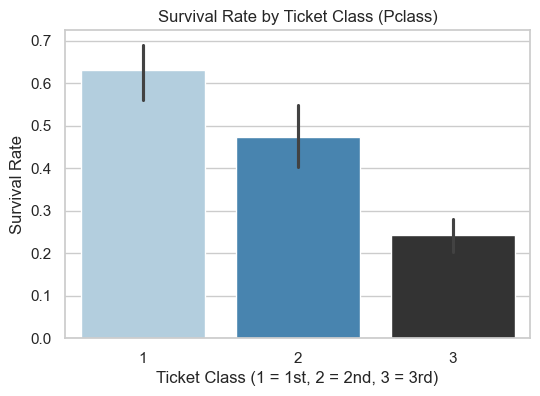

In [28]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d',hue='Pclass', legend=False)
plt.title('Survival Rate by Ticket Class (Pclass)')
plt.xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Survival Rate')
plt.show()

* **Insight:** There is a strong and clear correlation between the ticket class  and the survival rate. Passengers in the **1st Class** had the highest probability of survival (over 60%), followed by the 2nd Class, while passengers in the **3rd Class** had the lowest survival rate (around 24%). This confirms that social status and cabin location closer to the lifeboats played a critical role in rescue priority.

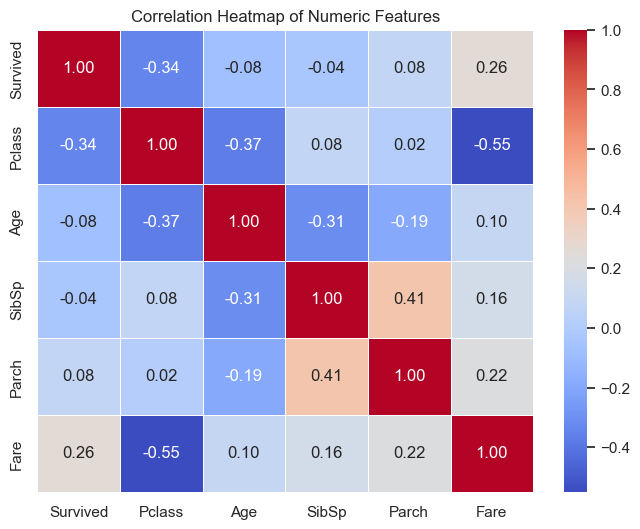

In [29]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['PassengerId'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

* **Insight:** The correlation matrix reveals crucial relationships among the features:
  * **Negative Correlation between Pclass and Survived:** As the class number increases (e.g., moving from 1st to 3rd class), the survival rate drops significantly.
  * **Positive Correlation between Fare and Survived:** Passengers who paid higher fares had better chances of survival, which directly aligns with them being in the more privileged 1st Class.

# Data Preprocessing

In [30]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [31]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [32]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [33]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [34]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [35]:
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (712, 8)
Testing Features: (179, 8)
Training Target: (712,)
Testing Target: (179,)


# Model Implementation

In [37]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

# Model Evaluation

In [41]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
4,Fare,0.274717
5,Sex_male,0.269253
1,Age,0.253254
0,Pclass,0.083476
2,SibSp,0.050237
3,Parch,0.037393
7,Embarked_S,0.021824
6,Embarked_Q,0.009845


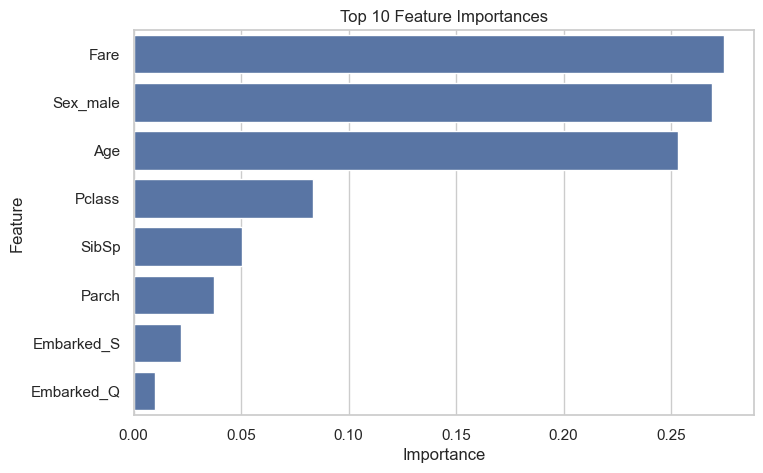

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.show()

In [40]:
y_pred = rf_model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Random Forest:")
print("="*45)
print(f" precision: {precision:.2f}")
print(f" recall   : {recall:.2f}")
print(f" f1       : {f1:.2f}")
print("="*45)
print(f"confusion matrix:\n{cm}")
print("="*45)
print(f"classification report:\n{cr}")

Random Forest:
 precision: 0.80
 recall   : 0.77
 f1       : 0.79
confusion matrix:
[[91 14]
 [17 57]]
classification report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85       105
           1       0.80      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

